QTrade - Task 2: State Transition Function & Reward Function

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

1. Load MSFT Data

In [3]:
df = yf.download("MSFT", start="2018-01-01", end="2023-12-31",
                 progress=False)
df = df[["Close"]].copy()
df.columns = ["Close"]
 
# Compute daily price change (Close_t - Close_{t-1})
df["price_change"] = df["Close"].diff()
 
# Drop the first row (NaN from diff)
df = df.dropna().reset_index()
 
print(f"Data loaded: {len(df)} trading days")
print(df.head())

Data loaded: 1508 trading days
        Date      Close  price_change
0 2018-01-03  79.237404      0.367058
1 2018-01-04  79.934814      0.697411
2 2018-01-05  80.925850      0.991035
3 2018-01-08  81.008453      0.082603
4 2018-01-09  80.953392     -0.055061


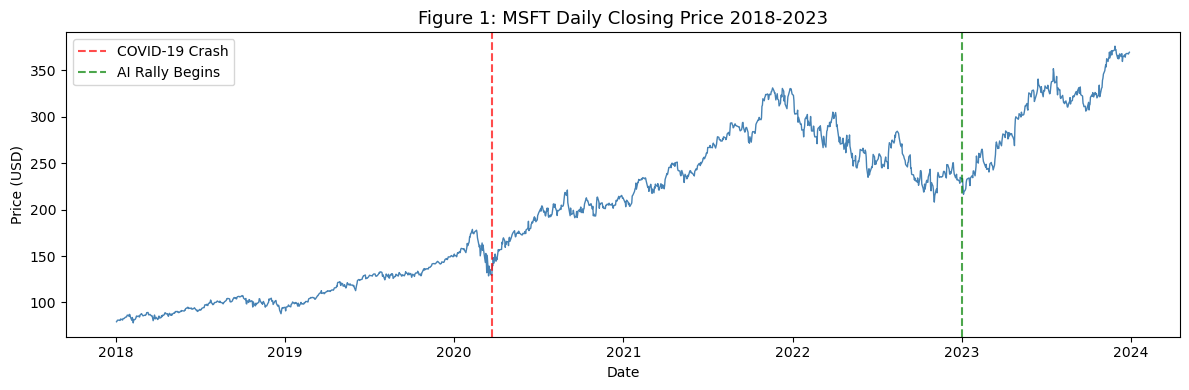

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df["Date"], df["Close"], color='steelblue', linewidth=1)

ax.axvline(pd.Timestamp("2020-03-23"), color='red', linestyle='--', 
           alpha=0.7, label="COVID-19 Crash")
ax.axvline(pd.Timestamp("2023-01-01"), color='green', linestyle='--', 
           alpha=0.7, label="AI Rally Begins")

ax.set_title("Figure 1: MSFT Daily Closing Price 2018-2023", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.savefig("msft_price.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. Defining the 4 States
Q-Table

In [4]:
def get_state(price_change, holding):
    if price_change >= 0 and holding == 1:
        return 0
    elif price_change >= 0 and holding == 0:
        return 1
    elif price_change < 0 and holding == 1:
        return 2
    else:
        return 3

S = ['s0', 's1', 's2', 's3']
A = ['hold', 'buy', 'sell']

print("States:", S)
print("Actions:", A)

States: ['s0', 's1', 's2', 's3']
Actions: ['hold', 'buy', 'sell']


## Reward Matrix

In [5]:
R = np.full((4, 3), np.nan)

up_days = df[df["price_change"] >= 0]["price_change"]
down_days = df[df["price_change"] < 0]["price_change"]

avg_up = up_days.mean()
avg_down = down_days.mean()

print(f"Average price change on up days: £{avg_up:.2f}")
print(f"Average price change on down days: £{avg_down:.2f}")

Average price change on up days: £2.67
Average price change on down days: £-2.77


In [7]:
R = np.full((4, 3), np.nan)

R[0, 0] = round(avg_up / 10, 4)
R[0, 1] = np.nan
R[0, 2] = round(avg_up, 4)

R[1, 0] = 0
R[1, 1] = 0
R[1, 2] = np.nan

R[2, 0] = round(avg_down / 10, 4)
R[2, 1] = np.nan
R[2, 2] = round(avg_down, 4)

R[3, 0] = 0
R[3, 1] = round(avg_up, 4)
R[3, 2] = np.nan

R_df = pd.DataFrame(R, index=S, columns=A)
print(R_df)

      hold     buy    sell
s0  0.2673     NaN  2.6729
s1  0.0000  0.0000     NaN
s2 -0.2771     NaN -2.7709
s3  0.0000  2.6729     NaN


PLOT:

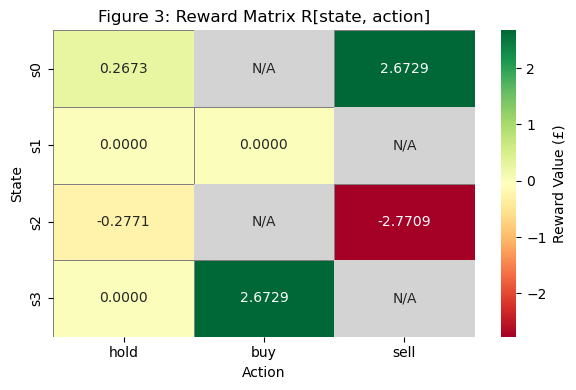

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

R_display = R_df.copy().astype(object)
for i in range(4):
    for j in range(3):
        if pd.isna(R[i, j]):
            R_display.iloc[i, j] = 'N/A'
        else:
            R_display.iloc[i, j] = f"{R[i, j]:.4f}"

mask = np.isnan(R)

sns.heatmap(R,
            annot=R_display,
            fmt='',
            mask=mask,
            cmap='RdYlGn',
            linewidths=0.5,
            linecolor='grey',
            cbar_kws={'label': 'Reward Value (£)'},
            xticklabels=A,
            yticklabels=S,
            ax=ax)

sns.heatmap(np.where(mask, 0, np.nan),
            cmap=['#d3d3d3'],
            annot=pd.DataFrame(
                [['N/A' if mask[i,j] else '' for j in range(3)]
                 for i in range(4)],
                index=S, columns=A),
            fmt='',
            cbar=False,
            xticklabels=A,
            yticklabels=S,
            ax=ax)

ax.set_title("Figure 3: Reward Matrix R[state, action]", fontsize=12)
ax.set_xlabel("Action")
ax.set_ylabel("State")
plt.tight_layout()
plt.savefig("reward_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## Probability Matrix

In [8]:
trans_count = np.zeros((4, 4))

holding = 0
for i in range(len(df) - 1):
    change_today    = df.loc[i, "price_change"]
    change_tomorrow = df.loc[i + 1, "price_change"]

    current_state = get_state(change_today, holding)

    action = np.random.randint(0, 3)

    if action == 0 and holding == 0:
        holding = 1
    elif action == 1 and holding == 1:
        holding = 0

    next_state = get_state(change_tomorrow, holding)
    trans_count[current_state, next_state] += 1

row_sums = trans_count.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
trans_prob = trans_count / row_sums

trans_df = pd.DataFrame(
    np.round(trans_prob, 3),
    index=[f"{s} (current)" for s in S],
    columns=[f"{s} (next)" for s in S]
)
print(trans_df)

              s0 (next)  s1 (next)  s2 (next)  s3 (next)
s0 (current)      0.375      0.170      0.278      0.178
s1 (current)      0.136      0.362      0.143      0.360
s2 (current)      0.399      0.190      0.299      0.112
s3 (current)      0.178      0.380      0.148      0.295


PLOT:

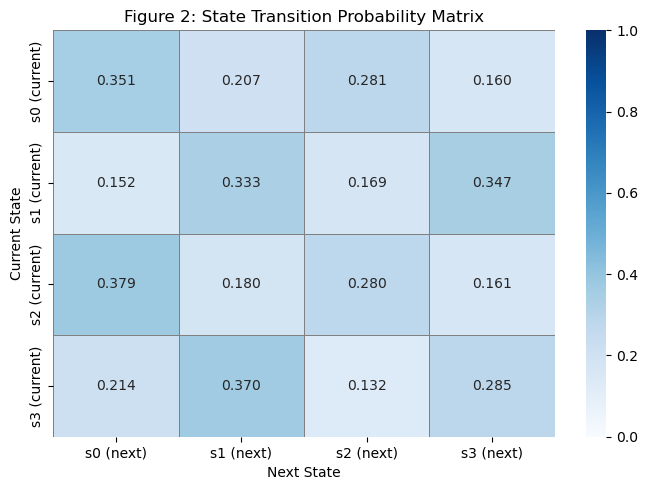

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(trans_prob,
            annot=True,
            fmt='.3f',
            cmap='Blues',
            linewidths=0.5,
            linecolor='grey',
            xticklabels=[f"{s} (next)" for s in S],
            yticklabels=[f"{s} (current)" for s in S],
            vmin=0, vmax=1,
            ax=ax)

ax.set_title("Figure 2: State Transition Probability Matrix", fontsize=12)
ax.set_xlabel("Next State")
ax.set_ylabel("Current State")
plt.tight_layout()
plt.savefig("transition_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## Task 3: Setting up the Q-learning parameters and policy

initializing the Q-table

In [9]:
Q = np.zeros((4, 3))

Q_df = pd.DataFrame(Q, index=S, columns=A)

print("Initial Q-table:")
print(Q_df)


Initial Q-table:
    hold  buy  sell
s0   0.0  0.0   0.0
s1   0.0  0.0   0.0
s2   0.0  0.0   0.0
s3   0.0  0.0   0.0


In [10]:
alpha = 0.5
gamma = 0.9
epsilon = 0.9
epsilon_decay = 0.995
epsilon_min = 0.01

print(f"Learning rate: {alpha}")
print(f"Discount factor: {gamma}")
print(f"Initial epsilon: {epsilon}")
print(f"Epsilon decay: {epsilon_decay}")
print(f"Minimum epsilon: {epsilon_min}")

Learning rate: 0.5
Discount factor: 0.9
Initial epsilon: 0.9
Epsilon decay: 0.995
Minimum epsilon: 0.01


alpha = 0.5 - The learning rate. i set this to 0.5 meaning the agent updates its Q-values at a moderate pace, it takes new information seriously but doesn't completely overwrite what it has already learned.
gamma = 0.9 - The discount factor. I set this high at 0.9 because in trading, future rewards matter enormously. A patient trader who holds a winning position earns more than one who panics and sells immediately.
epsilon = 0.9 - The starting exploration rate. The agent begins by exploring randomly 90% of the time.
epsilon_decay = 0.995 - After every episode epsilon is multiplied by this value, slowly reducing exploration over time.
epsilon_min = 0.01 - A floor on epsilon so the agent never completely stops exploring. Even a fully trained agent keeps 1% random exploration to avoid getting permanently stuck in a suboptimal policy.

defining epsilon

In [25]:
def epsilon_greedy_masked(Q, state, epsilon, holding):
    # define which actions are valid per state
    if holding == 1:
        valid_actions = [0, 2]   # can only hold or sell
    else:
        valid_actions = [0, 1]   # can only hold or buy

    if np.random.uniform(0, 1) < epsilon:
        return np.random.choice(valid_actions)   # explore valid only
    else:
        q_masked = Q[state].copy()
        # mask invalid actions with -inf so argmax ignores them
        for a in range(3):
            if a not in valid_actions:
                q_masked[a] = -np.inf
        return np.argmax(q_masked)

defining softmax

In [12]:
def softmax(state, Q, temperature=1.0):
    q_values = Q[state]
    exp_q = np.exp((q_values - np.max(q_values)) / temperature)
    probabilities = exp_q / np.sum(exp_q)
    return np.random.choice(len(q_values), p=probabilities)

print("Softmax policy defined")

Softmax policy defined


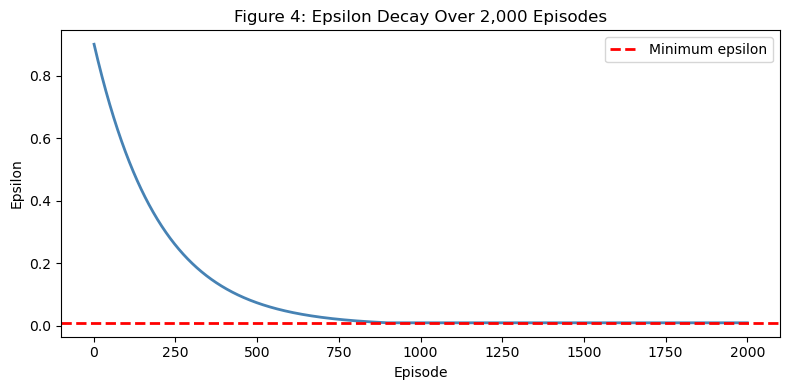

In [26]:
episodes = np.arange(1, 2001)
epsilons = []
eps_plot = epsilon

for e in episodes:
    epsilons.append(eps_plot)
    if eps_plot > epsilon_min:
        eps_plot *= epsilon_decay

plt.figure(figsize=(8, 4))
plt.plot(episodes, epsilons, color='steelblue', linewidth=2)
plt.axhline(y=epsilon_min, color='r', linestyle='--', linewidth=2, label='Minimum epsilon')
plt.title("Figure 4: Epsilon Decay Over 2,000 Episodes")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.legend()
plt.tight_layout()
plt.savefig("epsilon_decay.png", dpi=150, bbox_inches='tight')
plt.show()

## Q-learning Training loop

In [30]:
Q = np.zeros((4, 3))
episode_rewards = []
eps = epsilon

episode_data = df.tail(300).reset_index(drop=True)

for episode in range(2000):
    holding = np.random.randint(0, 2)
    total_reward = 0

    for t in range(len(episode_data) - 1):
        price_change = episode_data.loc[t, "price_change"]
        state = get_state(price_change, holding)

        action = epsilon_greedy_masked(Q, state, eps, holding)

        if action == 1 and holding == 0:
            holding = 1
        elif action == 2 and holding == 1:
            holding = 0

        reward = R[state, action]
        if np.isnan(reward):
            reward = 0

        next_price_change = episode_data.loc[t + 1, "price_change"]
        next_state = get_state(next_price_change, holding)

        best_next = np.nanmax(Q[next_state])
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * best_next - Q[state, action]
        )

        total_reward += reward

    if eps > epsilon_min:
        eps *= epsilon_decay

    episode_rewards.append(total_reward)

    if episode % 200 == 0:
        print(f"Episode {episode} -- Total Reward: £{total_reward:.2f} -- Epsilon: {eps:.4f}")

print("\nTraining complete")
print("\nFinal Q-Table:")
print(pd.DataFrame(np.round(Q, 4), index=S, columns=A))

Episode 0 -- Total Reward: £102.92 -- Epsilon: 0.8955
Episode 200 -- Total Reward: £301.47 -- Epsilon: 0.3286
Episode 400 -- Total Reward: £369.64 -- Epsilon: 0.1206
Episode 600 -- Total Reward: £364.20 -- Epsilon: 0.0443
Episode 800 -- Total Reward: £389.06 -- Epsilon: 0.0162
Episode 1000 -- Total Reward: £382.61 -- Epsilon: 0.0100
Episode 1200 -- Total Reward: £382.07 -- Epsilon: 0.0100
Episode 1400 -- Total Reward: £391.83 -- Epsilon: 0.0100
Episode 1600 -- Total Reward: £385.38 -- Epsilon: 0.0100
Episode 1800 -- Total Reward: £383.28 -- Epsilon: 0.0100

Training complete

Final Q-Table:
       hold      buy     sell
s0  12.2600   0.0000  15.2657
s1   8.8017  13.0176   0.0000
s2  13.8907   0.0000   8.1525
s3  11.8109  16.7622   0.0000


Policy converged to is greedy with buy on a dip strategy

In [31]:
policy_labels = ['hold', 'buy', 'sell']
print("Converged Policy:")
print("─" * 35)
for i, s in enumerate(S):
    best_action = policy_labels[np.argmax(Q[i])]
    print(f"  {s}: {best_action.upper()}")

Converged Policy:
───────────────────────────────────
  s0: SELL
  s1: BUY
  s2: HOLD
  s3: BUY


Plot Reward Per Episode

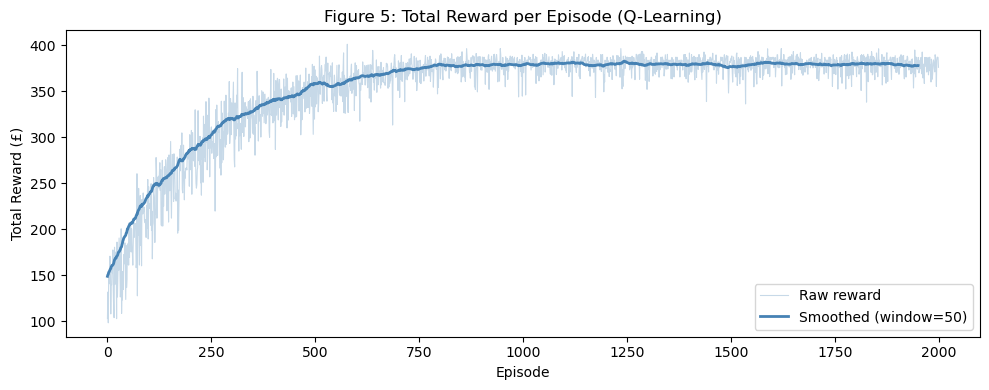

In [33]:
def smooth(values, window=50):
    return np.convolve(values, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.3, color='steelblue', linewidth=0.8, label='Raw reward')
plt.plot(smooth(episode_rewards), color='steelblue', linewidth=2, label='Smoothed (window=50)')
plt.title("Figure 5: Total Reward per Episode (Q-Learning)")
plt.xlabel("Episode")
plt.ylabel("Total Reward (£)")
plt.legend()
plt.tight_layout()
plt.savefig("reward_per_episode.png", dpi=150, bbox_inches='tight')
plt.show()

## Task 6: Repeating the experiment with different parameter values and policy.

Alpha test: Baseline = 0.5

In [34]:
alphas_to_test = [0.2, 0.5, 0.9]
alpha_results = {}

for a in alphas_to_test:
    Q_test = np.zeros((4, 3))
    rewards = []
    eps = epsilon

    for episode in range(2000):
        holding = np.random.randint(0, 2)
        total_reward = 0

        for t in range(len(episode_data) - 1):
            price_change = episode_data.loc[t, "price_change"]
            state = get_state(price_change, holding)
            action = epsilon_greedy_masked(Q_test, state, eps, holding)

            if action == 1 and holding == 0:
                holding = 1
            elif action == 2 and holding == 1:
                holding = 0

            reward = R[state, action]
            if np.isnan(reward):
                reward = 0

            next_price_change = episode_data.loc[t + 1, "price_change"]
            next_state = get_state(next_price_change, holding)

            best_next = np.nanmax(Q_test[next_state])
            Q_test[state, action] += a * (reward + gamma * best_next - Q_test[state, action])

            total_reward += reward

        if eps > epsilon_min:
            eps *= epsilon_decay

        rewards.append(total_reward)

    alpha_results[a] = rewards
    print(f"alpha={a} done — final avg reward: £{np.mean(rewards[-100:]):.2f}")

alpha=0.2 done — final avg reward: £381.44
alpha=0.5 done — final avg reward: £378.35
alpha=0.9 done — final avg reward: £369.01


PLOT

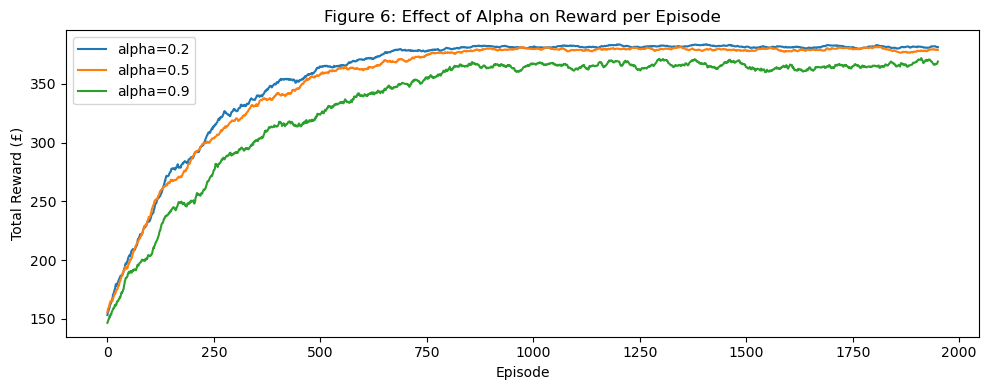

In [35]:
plt.figure(figsize=(10, 4))
for a, rewards in alpha_results.items():
    plt.plot(smooth(rewards), label=f'alpha={a}')

plt.title("Figure 6: Effect of Alpha on Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward (£)")
plt.legend()
plt.tight_layout()
plt.savefig("alpha_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Gamma Test: [0.2, 0.5, 0.9] with evrything else fixed
alpha = 0.5, epsilon decay = 0.995.

In [36]:
gammas_to_test = [0.2, 0.5, 0.9]
gamma_results = {}

for g in gammas_to_test:
    Q_test = np.zeros((4, 3))
    rewards = []
    eps = epsilon

    for episode in range(2000):
        holding = np.random.randint(0, 2)
        total_reward = 0

        for t in range(len(episode_data) - 1):
            price_change = episode_data.loc[t, "price_change"]
            state = get_state(price_change, holding)
            action = epsilon_greedy_masked(Q_test, state, eps, holding)

            if action == 1 and holding == 0:
                holding = 1
            elif action == 2 and holding == 1:
                holding = 0

            reward = R[state, action]
            if np.isnan(reward):
                reward = 0

            next_price_change = episode_data.loc[t + 1, "price_change"]
            next_state = get_state(next_price_change, holding)

            best_next = np.nanmax(Q_test[next_state])
            Q_test[state, action] += alpha * (reward + g * best_next - Q_test[state, action])

            total_reward += reward

        if eps > epsilon_min:
            eps *= epsilon_decay

        rewards.append(total_reward)

    gamma_results[g] = rewards
    print(f"gamma={g} done — final avg reward: £{np.mean(rewards[-100:]):.2f}")

gamma=0.2 done — final avg reward: £381.87
gamma=0.5 done — final avg reward: £382.15
gamma=0.9 done — final avg reward: £380.58


PLOT

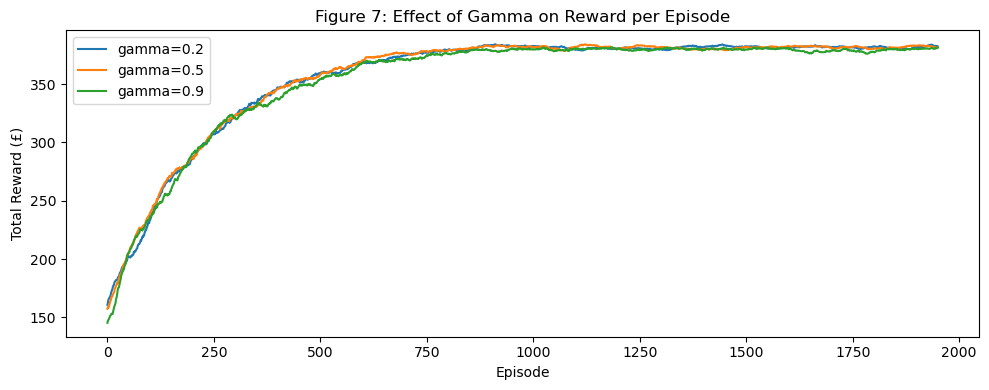

In [37]:
plt.figure(figsize=(10, 4))
for g, rewards in gamma_results.items():
    plt.plot(smooth(rewards), label=f'gamma={g}')

plt.title("Figure 7: Effect of Gamma on Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward (£)")
plt.legend()
plt.tight_layout()
plt.savefig("gamma_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Epsilon Test

In [38]:
decays_to_test = [0.99, 0.995, 0.999]
decay_results = {}

for d in decays_to_test:
    Q_test = np.zeros((4, 3))
    rewards = []
    eps = epsilon

    for episode in range(2000):
        holding = np.random.randint(0, 2)
        total_reward = 0

        for t in range(len(episode_data) - 1):
            price_change = episode_data.loc[t, "price_change"]
            state = get_state(price_change, holding)
            action = epsilon_greedy_masked(Q_test, state, eps, holding)

            if action == 1 and holding == 0:
                holding = 1
            elif action == 2 and holding == 1:
                holding = 0

            reward = R[state, action]
            if np.isnan(reward):
                reward = 0

            next_price_change = episode_data.loc[t + 1, "price_change"]
            next_state = get_state(next_price_change, holding)

            best_next = np.nanmax(Q_test[next_state])
            Q_test[state, action] += alpha * (reward + gamma * best_next - Q_test[state, action])

            total_reward += reward

        if eps > epsilon_min:
            eps *= d

        rewards.append(total_reward)

    decay_results[d] = rewards
    print(f"decay={d} done — final avg reward: £{np.mean(rewards[-100:]):.2f}")

decay=0.99 done — final avg reward: £378.66
decay=0.995 done — final avg reward: £377.05
decay=0.999 done — final avg reward: £331.24


PLOT

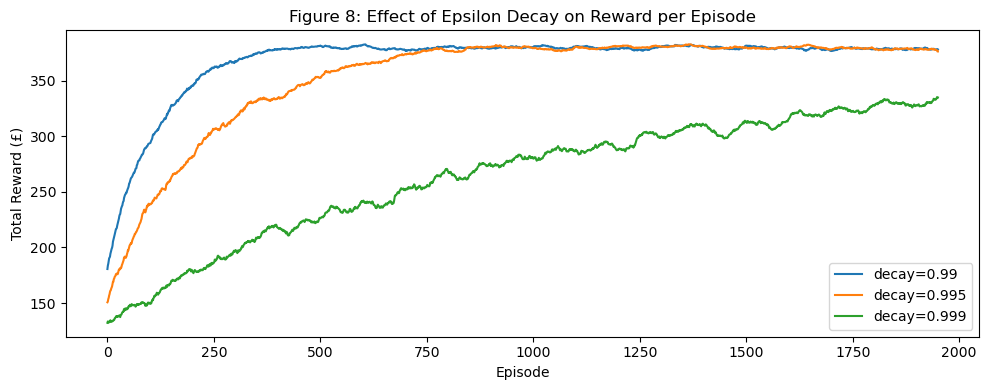

In [39]:
plt.figure(figsize=(10, 4))
for d, rewards in decay_results.items():
    plt.plot(smooth(rewards), label=f'decay={d}')

plt.title("Figure 8: Effect of Epsilon Decay on Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward (£)")
plt.legend()
plt.tight_layout()
plt.savefig("epsilon_decay_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Policy: Softmax Vs ε-greedy

In [40]:
policy_results = {}

# --- epsilon greedy ---
Q_eg = np.zeros((4, 3))
rewards_eg = []
eps = epsilon

for episode in range(2000):
    holding = np.random.randint(0, 2)
    total_reward = 0

    for t in range(len(episode_data) - 1):
        price_change = episode_data.loc[t, "price_change"]
        state = get_state(price_change, holding)
        action = epsilon_greedy_masked(Q_eg, state, eps, holding)

        if action == 1 and holding == 0:
            holding = 1
        elif action == 2 and holding == 1:
            holding = 0

        reward = R[state, action]
        if np.isnan(reward):
            reward = 0

        next_price_change = episode_data.loc[t + 1, "price_change"]
        next_state = get_state(next_price_change, holding)

        best_next = np.nanmax(Q_eg[next_state])
        Q_eg[state, action] += alpha * (reward + gamma * best_next - Q_eg[state, action])

        total_reward += reward

    if eps > epsilon_min:
        eps *= epsilon_decay

    rewards_eg.append(total_reward)

policy_results['epsilon-greedy'] = rewards_eg
print(f"epsilon-greedy done — final avg reward: £{np.mean(rewards_eg[-100:]):.2f}")

# --- softmax ---
Q_sm = np.zeros((4, 3))
rewards_sm = []

for episode in range(2000):
    holding = np.random.randint(0, 2)
    total_reward = 0

    for t in range(len(episode_data) - 1):
        price_change = episode_data.loc[t, "price_change"]
        state = get_state(price_change, holding)
        action = softmax(state, Q_sm, temperature=1.0)

        if action == 1 and holding == 0:
            holding = 1
        elif action == 2 and holding == 1:
            holding = 0

        reward = R[state, action]
        if np.isnan(reward):
            reward = 0

        next_price_change = episode_data.loc[t + 1, "price_change"]
        next_state = get_state(next_price_change, holding)

        best_next = np.nanmax(Q_sm[next_state])
        Q_sm[state, action] += alpha * (reward + gamma * best_next - Q_sm[state, action])

        total_reward += reward

    rewards_sm.append(total_reward)

policy_results['softmax'] = rewards_sm
print(f"softmax done — final avg reward: £{np.mean(rewards_sm[-100:]):.2f}")

epsilon-greedy done — final avg reward: £379.81
softmax done — final avg reward: £386.69


PLOT

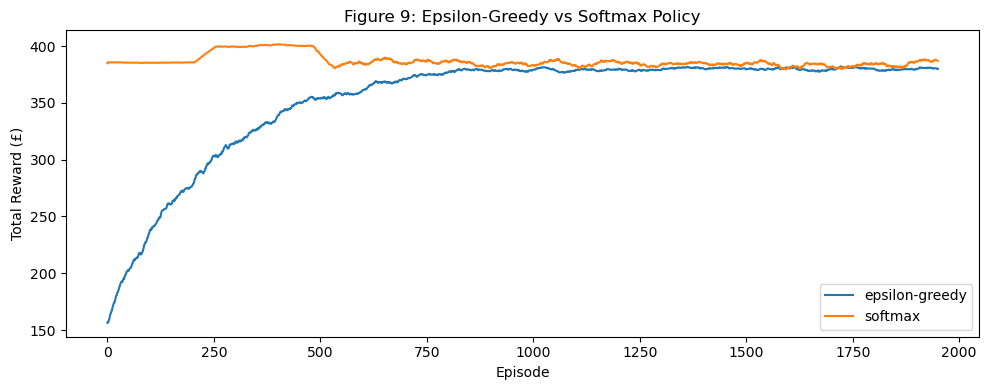

In [41]:
plt.figure(figsize=(10, 4))
for label, rewards in policy_results.items():
    plt.plot(smooth(rewards), label=label)

plt.title("Figure 9: Epsilon-Greedy vs Softmax Policy")
plt.xlabel("Episode")
plt.ylabel("Total Reward (£)")
plt.legend()
plt.tight_layout()
plt.savefig("policy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()